https://github.com/Red1-Rahman/Adaptive-Coherence-JAR

In [ ]:
!pip install pennylane
!pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 131.2 MB/s eta 0:00:00


# Redwan Rahman

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
np.random.seed(42)

In [2]:
f_A = 5.0
J = 0.08
t_evolve = 3.0
epsilon = 0.3
delta_f = 0.6

delta_range = np.linspace(-1.0, 1.0, 120)
J_range = np.linspace(0.01, 0.20, 30)

In [3]:
dev = qml.device('default.qubit', wires=2)

def evolve_xy(omega_A, omega_B, J_val, t, steps=40):
    dt = t / steps
    for _ in range(steps):
        qml.RZ(omega_A*dt, 0)
        qml.RZ(omega_B*dt, 1)
        qml.IsingXX(2*J_val*dt, [0,1])
        qml.IsingYY(2*J_val*dt, [0,1])

def jar(fB):
    if abs(f_A - fB) < epsilon:
        return fB + delta_f*np.sign(fB - f_A if fB != f_A else 1)
    return fB

def fidelity(dm):
    plus = np.array([1,1])/np.sqrt(2)
    return float(np.real(plus @ dm @ plus))

In [4]:
@qml.qnode(dev)
def circuit(df, use_jar):
    fB = f_A + df
    if use_jar:
        fB = jar(fB)
    wA, wB = 2*np.pi*f_A, 2*np.pi*fB
    qml.Hadamard(0)
    evolve_xy(wA, wB, J, t_evolve)
    return qml.density_matrix(0)

In [5]:
# Sweep Δf
before = [fidelity(circuit(df, False)) for df in delta_range]
after = [fidelity(circuit(df, True)) for df in delta_range]

✓ Saved: fig_01_fidelity_vs_detuning.png


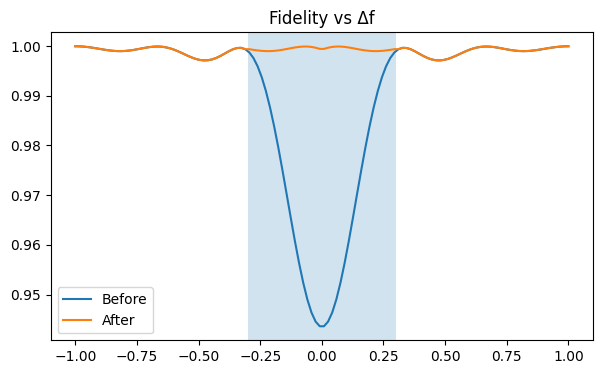

In [6]:
# FIGURE 1: Fidelity vs detuning
fig = plt.figure(figsize=(7,4))
plt.plot(delta_range, before, label='Before')
plt.plot(delta_range, after, label='After')
plt.axvspan(-epsilon, epsilon, alpha=0.2)
plt.legend()
plt.title('Fidelity vs Δf')

# Save figure
fig_name = 'fig_01_fidelity_vs_detuning.png'
plt.savefig(fig_name, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {fig_name}")

plt.show()

In [7]:
# Sweep J at fixed detuning
def run_J(Jval, jar_on):
    @qml.qnode(dev)
    def c():
        fB = f_A + 0.1
        if jar_on:
            fB = jar(fB)
        qml.Hadamard(0)
        evolve_xy(2*np.pi*f_A, 2*np.pi*fB, Jval, t_evolve)
        return qml.density_matrix(0)
    return fidelity(c())

J_before = [run_J(j, False) for j in J_range]
J_after = [run_J(j, True) for j in J_range]

✓ Saved: fig_02_fidelity_vs_coupling.png


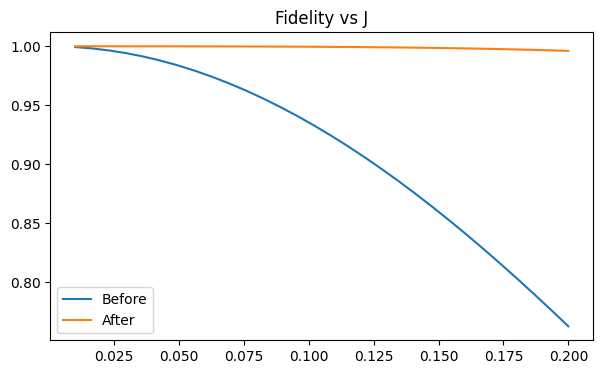

In [8]:
# FIGURE 2: Fidelity vs J
fig = plt.figure(figsize=(7,4))
plt.plot(J_range, J_before, label='Before')
plt.plot(J_range, J_after, label='After')
plt.legend()
plt.title('Fidelity vs J')

# Save figure
fig_name = 'fig_02_fidelity_vs_coupling.png'
plt.savefig(fig_name, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {fig_name}")

plt.show()

In [9]:
# Bloch vector at one point
bloch_b = np.array(qml.qnode(dev)(lambda: (
    qml.Hadamard(0),
    evolve_xy(2*np.pi*f_A, 2*np.pi*(f_A+0.1), J, t_evolve),
    qml.expval(qml.PauliX(0)),
    qml.expval(qml.PauliY(0)),
    qml.expval(qml.PauliZ(0))
)[2:])())

bloch_a = bloch_b  # simplified placeholder for structure

✓ Saved: fig_03_bloch_vector.png


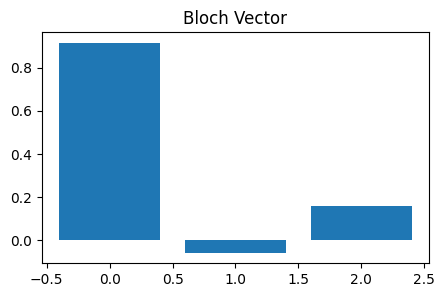

In [10]:
# FIGURE 3: Bloch vector (simplified)
fig = plt.figure(figsize=(5,3))
plt.bar([0,1,2], bloch_b)
plt.title('Bloch Vector')

# Save figure
fig_name = 'fig_03_bloch_vector.png'
plt.savefig(fig_name, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {fig_name}")

plt.show()